<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/29_Hypothesis_Testing_in_Python/02_Two-Sample_and_ANOVA_Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [5]:

import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/29_Hypothesis_Testing_in_Python/dataset/late_shipments.feather"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
late_shipments = pd.read_feather(url)
display(late_shipments.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/churn.csv"
# Read the CSV file
churn = pd.read_csv(url)
display(churn.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/ad_conversion.csv"
# Read the CSV file
ad_conversion = pd.read_csv(url)
display(ad_conversion.head())

,id,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,late_delivery,late,product_group,sub_classification,...,line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_kilograms,freight_cost_usd,freight_cost_groups,line_item_insurance_usd
0,36203.0,Nigeria,PMO - US,Direct Drop,EXW,Air,1.0,Yes,HRDT,HIV test,...,2996.0,266644.00,89.00,0.89,"Alere Medical Co., Ltd.",Yes,1426.0,33279.83,expensive,373.83
1,30998.0,Botswana,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,25.0,800.00,32.00,1.60,"Trinity Biotech, Plc",Yes,10.0,559.89,reasonable,1.72
2,69871.0,Vietnam,PMO - US,Direct Drop,EXW,Air,0.0,No,ARV,Adult,...,22925.0,110040.00,4.80,0.08,Hetero Unit III Hyderabad IN,Yes,3723.0,19056.13,expensive,181.57
3,17648.0,South Africa,PMO - US,Direct Drop,DDP,Ocean,0.0,No,ARV,Adult,...,152535.0,361507.95,2.37,0.04,"Aurobindo Unit III, India",Yes,7698.0,11372.23,expensive,779.41
4,5647.0,Uganda,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test - Ancillary,...,850.0,8.50,0.01,0.00,Inverness Japan,Yes,56.0,360.00,reasonable,0.01


,has_churned,time_since_first_purchase,time_since_last_purchase
0,0,-1.089221,-0.721322
1,0,1.182983,3.634435
2,0,-0.846156,-0.427582
3,0,0.086942,-0.535672
4,0,-1.166642,-0.672640


,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


### Hypothesis testing workflow
You've seen the hypothesis testing workflow for the one sample case where you compared a sample mean to a hypothesized value, and the two sample case where you compared two sample means. In both cases, the workflow shares common steps.

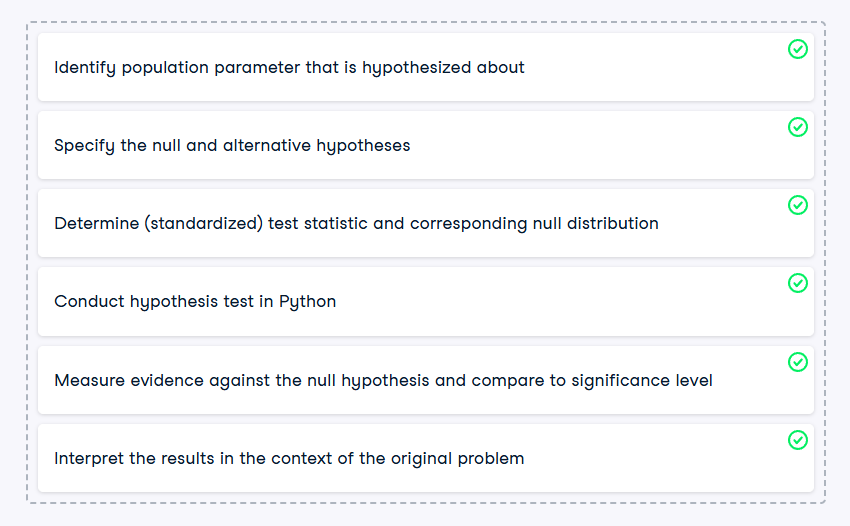

 Regardless of the type of hypothesis test you are performing, it will have a workflow that follows this format.

**Two sample mean test statistic**  
The hypothesis test for determining if there is a difference between the means of two populations uses a different type of test statistic to the z-scores you saw in Chapter 1. It's called "t", and it can be calculated from three values from each sample using this equation.


 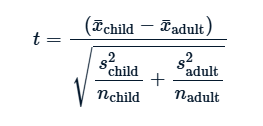


While trying to determine why some shipments are late, you may wonder if the weight of the shipments that were on time is less than the weight of the shipments that were late. The late_shipments dataset has been split into a "yes" group, where late == "Yes" and a "no" group where late == "No". The weight of the shipment is given in the weight_kilograms variable.

The sample means for the two groups are available as xbar_no and xbar_yes. The sample standard deviations are s_no and s_yes. The sample sizes are n_no and n_yes. numpy is also loaded as np.

In [13]:
# Calculate the mean, standard deviation, and sample size for each group
xbar_no = 1897.7912673056444
xbar_yes = 2715.6721311475408
s_no = 3154.0395070841687
s_yes = 2544.688210903328
n_no = 939
n_yes = 61

# Calculate the numerator of the test statistic
numerator = xbar_no - xbar_yes

# Calculate the denominator of the test statistic
denominator = np.sqrt(s_no ** 2 / n_no + s_yes ** 2 / n_yes)

# Calculate the test statistic
t_stat = numerator/denominator

# Print the test statistic
print(t_stat)

# When testing for differences between means, the test statistic is called 't'
#  rather than 'z', and can be calculated using six numbers from the samples.
#  Here, the value is about -2.39 or 2.39, depending on the order you calculated the numerator.


# Using a sample standard deviation to estimate the standard error is computationally
# easier than using bootstrapping. However, to correct for the approximation,
#  you need to use a t-distribution when transforming the test statistic to get the p-value.

-2.3936661778766433


**The t-distribution**  
The t-distribution is used to calculate the p-value from the
 test statistic, and having a sense of how the PDF and CDF look can help you understand this calculation. It has two parameters: the degrees of freedom, and the non-centrality parameter.

The plots show the PDF and CDF for a t-distribution (solid black line), and for comparison show a standard normal distribution with mean 0 and variance 1 (gray dotted line).

*Which statement about the the t-distribution is true?*

- As you increase the degrees of freedom, the t-distribution PDF and CDF curves get closer to those of a normal distribution.

*The normal distribution is essentially a t-distribution with infinite degrees of freedom.*

**From t to p**  
Previously, you calculated the test statistic for the two-sample problem of whether the mean weight of shipments is smaller for shipments that weren't late (late == "No") compared to shipments that were late (late == "Yes"). In order to make decisions about it, you need to transform the test statistic with a cumulative distribution function to get a p-value.

Recall the hypotheses:

`H0`: The mean weight of shipments that weren't late is the same as the mean weight of shipments that were late.

`HA`: The mean weight of shipments that weren't late is less than the mean weight of shipments that were late.

The test statistic, t_stat, is available, as are the samples sizes for each group, n_no and n_yes. Use a significance level of alpha = 0.05.

t has also been imported from scipy.stats.

*? What type of test does the alternative hypothesis indicate that we need?*

- Left tailed

In [15]:
# Calculate the degrees of freedom
degrees_of_freedom = n_no + n_yes -2

# Calculate the p-value from the test stat
from scipy.stats import t
p_value = t.cdf(t_stat, df=degrees_of_freedom)

# Print the p_value
print(p_value)

# ?What decision should you make based on the results of the hypothesis test?
# -> Reject the null hypothesis.

# -value predictions! When the standard error is estimated from the sample
# standard deviation and sample size, the test statistic is transformed into a p-value using the t-distribution.

0.008432382146249523


**Is pairing needed?**  
t-tests are used to compare two sample means. However, the test involves different calculations depending upon whether the two samples are paired or not. To make sure you use the correct version of the t-test, you need to be able to identify pairing.

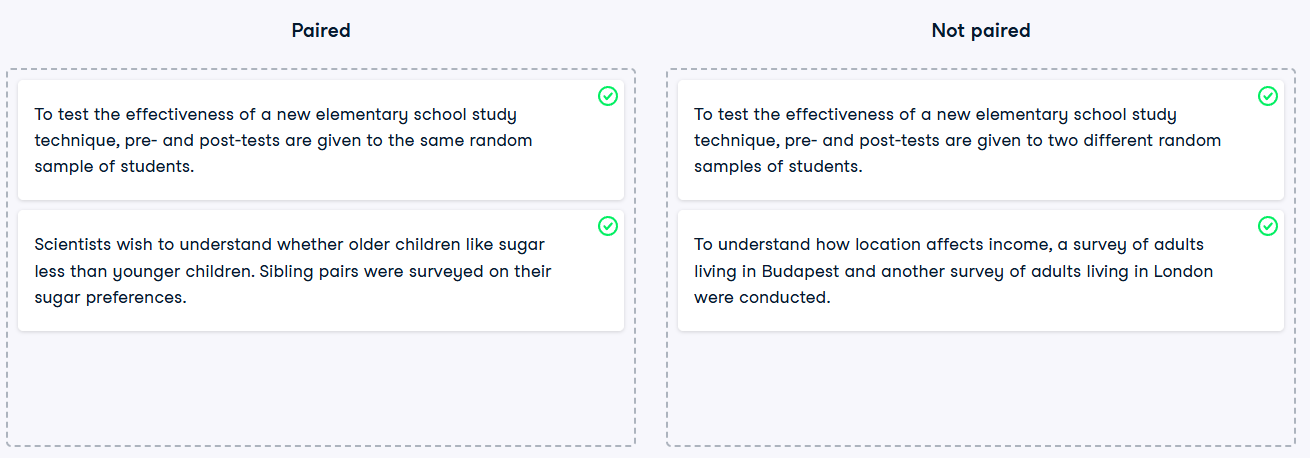

 If you have repeated observations of something, then those observations form pairs.

**Visualizing the difference**  
Before you start running hypothesis tests, it's a great idea to perform some exploratory data analysis; that is, calculating summary statistics and visualizing distributions.

Here, you'll look at the proportion of county-level votes for the Democratic candidate in 2012 and 2016, sample_dem_data. Since the counties are the same in both years, these samples are paired. The columns containing the samples are dem_percent_12 and dem_percent_16.

`dem_votes_potus_12_16` is available as sample_dem_data. pandas and matplotlib.pyplot are loaded with their usual aliases.



In [ ]:
# Calculate the differences from 2012 to 2016
sample_dem_data['diff'] = sample_dem_data['dem_percent_12'] - sample_dem_data['dem_percent_16']

# Find the mean of the diff column
xbar_diff = sample_dem_data['diff'].mean()

# Find the standard deviation of the diff column
s_diff = sample_dem_data['diff'].std()

# Plot a histogram of diff with 20 bins
sample_dem_data['diff'].hist(bins=20)
plt.show()

# Notice that the majority of the histogram lies to the right of zero.



**Using ttest()**
Manually calculating test statistics and transforming them with a CDF to get a p-value is a lot of effort to compare two sample means. The comparison of two sample means is called a t-test, and the pingouin Python package has a .ttest() method to accomplish it. This method provides some flexibility in how you perform the test.

As in the previous exercise, you'll explore the difference between the proportion of county-level votes for the Democratic candidate in 2012 and 2016 to identify if the difference is significant. The hypotheses are as follows:

: The proportion of democratic votes in 2012 and 2016 were the same.
: The proportion of democratic votes in 2012 and 2016 were different.

sample_dem_data is available and has the columns diff, dem_percent_12, and dem_percent_16 in addition to the state and county names. pingouin and has been loaded along with pandas as pd.

In [ ]:
# Conduct a t-test on diff
test_results = pingouin.ttest(x=sample_dem_data['diff'],
                              y=0,
                              alternative="two-sided")

# What's the correct decision from the t-test, assuming a=0.01  -> Reject Null Hypo

# Conduct a paired t-test on dem_percent_12 and dem_percent_16
paired_test_results = pingouin.ttest(x=sample_dem_data['dem_percent_12'],
                                     y=sample_dem_data['dem_percent_16'],
                                     paired=True,
                                     alternative="two-sided")




# Print the paired test results
print(paired_test_results)

# Compare the paired t-test to an (inappropriate) unpaired test on the same data. How does the p-value change?
# ->he p-value from the unpaired test is greater than than the p-value from the paired test.L


# lets you avoid manual calculation to run your test. When you have paired data,
# a paired t-test is preferable to the unpaired version because it reduces the chance of a false negative error.



**Visualizing many categories**  
So far in this chapter, we've only considered the case of differences in a numeric variable between two categories. Of course, many datasets contain more categories. Before you get to conducting tests on many categories, it's often helpful to perform exploratory data analysis (EDA), calculating summary statistics for each group and visualizing the distributions of the numeric variable for each category using box plots.

Here, we'll return to the late shipments data, and how the price of each package (pack_price) varies between the three shipment modes (shipment_mode): "Air", "Air Charter", and "Ocean".

late_shipments is available; pandas and matplotlib.pyplot are loaded with their standard aliases, and seaborn is loaded as sns.

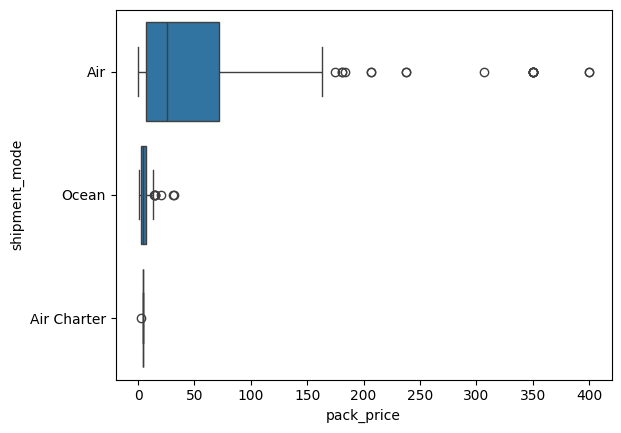

In [16]:
# Calculate the mean pack_price for each shipment_mode
xbar_pack_by_mode = late_shipments.groupby("shipment_mode")['pack_price'].mean()

# Calculate the standard deviation of the pack_price for each shipment_mode
s_pack_by_mode = late_shipments.groupby("shipment_mode")['pack_price'].std()

# Boxplot of shipment_mode vs. pack_price
sns.boxplot(x="pack_price", y="shipment_mode", data=late_shipments)
plt.show()

# There certainly looks to be a difference in the pack price between each of the three shipment modes. Do you think the differences are statistically significant?

Conducting an ANOVA test
The box plots made it look like the distribution of pack price was different for each of the three shipment modes. However, it didn't tell us whether the mean pack price was different in each category. To determine that, we can use an ANOVA test. The null and alternative hypotheses can be written as follows.

H0: Pack prices for every category of shipment mode are the same.

HA: Pack prices for some categories of shipment mode are different.

Use a significance level of 0.1.

late_shipments is available and pingouin has been loaded.

In [23]:
# Run an ANOVA for pack_price across shipment_mode
import pingouin as pg
anova_results = pg.anova(data=late_shipments, dv="pack_price", between="shipment_mode")



# Print anova_results
print(anova_results)

#  Assuming a significance level of 0.1, should you reject the null hypothesis that there is no difference in pack prices between shipment modes?
# -> Yes. The p-value is less than or equal to the significance level, so the null hypothesis should be rejected.

# There is a significant difference in pack prices between the shipment modes. However, we don't know which shipment modes this applies to.

          Source  ddof1  ddof2        F         p-unc       np2
0  shipment_mode      2    997  21.8646  5.089479e-10  0.042018


In [22]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.9 MB/s eta 0:00:00


**Pairwise t-tests**  
The ANOVA test didn't tell you which categories of shipment mode had significant differences in pack prices. To pinpoint which categories had differences, you could instead use pairwise t-tests.

late_shipments is available and pingouin has been loaded.

In [26]:
# Modify the pairwise t-tests to use Bonferroni p-value adjustment
import pingouin as pg
pairwise_results = pg.pairwise_tests(data=late_shipments,
                                           dv="pack_price",
                                           between="shipment_mode",
                                           padjust="bonf")

# Print pairwise_results
print(pairwise_results)

# ? Using the Bonferroni correction results and assuming a significance level of
# 0.1, for which pairs of shipment modes should you reject the null hypothesis that the pack prices are equal?

# -> "Ocean" and "Air Charter"; "Ocean" and "Air"; "Air Charter" and "Air".

# After applying the Bonferroni adjustment, the p-values for the t-tests between each of the three groups are all less than 0.1.

        Contrast            A            B  Paired  Parametric          T  \
0  shipment_mode          Air  Air Charter   False        True  21.179625   
1  shipment_mode          Air        Ocean   False        True  19.335760   
2  shipment_mode  Air Charter        Ocean   False        True  -3.170654   

          dof alternative         p-unc        p-corr p-adjust       BF10  \
0  600.685682   two-sided  8.748346e-75  2.624504e-74     bonf  5.809e+76   
1  986.979785   two-sided  6.934555e-71  2.080367e-70     bonf  1.129e+67   
2   35.615026   two-sided  3.123012e-03  9.369037e-03     bonf     15.277   

     hedges  
0  0.726592  
1  0.711119  
2 -0.423775  
